# Transformer Models — TON_IoT NLP Dataset
### Models: DistilBERT | BERT-base | RoBERTa-base
**Evaluation:** Accuracy, Precision, Recall, F1-Score, ROC-AUC, MCC, Cohen's Kappa, Confusion Matrix

> **Note:** GPU strongly recommended. DistilBERT is fastest; start with it to verify pipeline.

In [1]:
# Install if needed
# !pip install transformers datasets accelerate torch -q

import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, cohen_kappa_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
df = pd.read_csv('TON_IoT_NLP_Dataset.csv')
texts = df['text'].astype(str).tolist()
labels = df['label'].astype(int).tolist()

print('Dataset shape:', df.shape)
print('Label distribution:')
print(pd.Series(labels).value_counts())

Dataset shape: (211043, 3)
Label distribution:
1    161043
0     50000
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)
print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Train: 151950 | Val: 16884 | Test: 42209


In [4]:
# ─────────────────────────────────────────────────────────────
# Dataset Class
# ─────────────────────────────────────────────────────────────
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts    = texts
        self.labels   = labels
        self.tokenizer = tokenizer
        self.max_len  = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [5]:
# ─────────────────────────────────────────────────────────────
# Training & Evaluation Functions
# ─────────────────────────────────────────────────────────────
results_table = []

def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, total_correct = 0, 0
    for batch in loader:
        optimizer.zero_grad()
        ids   = batch['input_ids'].to(DEVICE)
        mask  = batch['attention_mask'].to(DEVICE)
        lbls  = batch['label'].to(DEVICE)
        out   = model(ids, attention_mask=mask, labels=lbls)
        loss  = out.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss    += loss.item()
        preds          = out.logits.argmax(dim=1)
        total_correct += (preds == lbls).sum().item()
    return total_loss / len(loader), total_correct / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, total_correct = 0, 0
    all_probs, all_preds, all_labels = [], [], []
    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['label'].to(DEVICE)
        out  = model(ids, attention_mask=mask, labels=lbls)
        total_loss += out.loss.item()
        probs  = torch.softmax(out.logits, dim=1)[:, 1].cpu().numpy()
        preds  = out.logits.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(lbls.cpu().numpy())
        total_correct += (out.logits.argmax(dim=1) == lbls).sum().item()
    return (total_loss/len(loader),
            total_correct/len(loader.dataset),
            np.array(all_probs),
            np.array(all_preds),
            np.array(all_labels))


def run_transformer(model_name, display_name,
                    max_len=128, epochs=4, batch_size=16, lr=2e-5):
    print(f'\n{"="*65}\n  Model: {display_name}\n  Checkpoint: {model_name}\n{"="*65}')

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    model.to(DEVICE)

    train_ds = TextDataset(X_train, y_train, tokenizer, max_len)
    val_ds   = TextDataset(X_val,   y_val,   tokenizer, max_len)
    test_ds  = TextDataset(X_test,  y_test,  tokenizer, max_len)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size*2)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size*2)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1*total_steps),
        num_training_steps=total_steps
    )

    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    best_val_loss = float('inf')

    t0 = time.time()
    for epoch in range(1, epochs+1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler)
        vl_loss, vl_acc, *_ = eval_epoch(model, val_loader)

        train_losses.append(tr_loss); val_losses.append(vl_loss)
        train_accs.append(tr_acc);   val_accs.append(vl_acc)

        print(f'  Epoch {epoch}/{epochs} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
              f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}')

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            torch.save(model.state_dict(), f'best_{display_name.replace(" ","_")}.pt')

    train_time = time.time() - t0

    # Load best checkpoint
    model.load_state_dict(torch.load(f'best_{display_name.replace(" ","_")}.pt'))

    t1 = time.time()
    _, _, y_prob, y_pred, y_true = eval_epoch(model, test_loader)
    infer_time = time.time() - t1

    # Metrics
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, average='weighted')
    rec   = recall_score(y_true, y_pred, average='weighted')
    f1    = f1_score(y_true, y_pred, average='weighted')
    auc   = roc_auc_score(y_true, y_prob)
    mcc   = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    params = sum(p.numel() for p in model.parameters())

    print(f'\n{"─"*65}')
    print(f'  Test Results — {display_name}')
    print(f'{"─"*65}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}  (weighted)')
    print(f'  Recall    : {rec:.4f}  (weighted)')
    print(f'  F1-Score  : {f1:.4f}  (weighted)')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  MCC       : {mcc:.4f}')
    print(f"  Cohen's κ : {kappa:.4f}")
    print(f'  Parameters: {params:,}')
    print(f'  Train Time: {train_time:.1f}s  |  Infer Time: {infer_time:.3f}s')
    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred, digits=4))

    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {display_name}')
    axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

    axes[1].plot(range(1, epochs+1), train_losses, label='Train Loss')
    axes[1].plot(range(1, epochs+1), val_losses,   label='Val Loss')
    axes[1].plot(range(1, epochs+1), train_accs,   label='Train Acc', linestyle='--')
    axes[1].plot(range(1, epochs+1), val_accs,     label='Val Acc',   linestyle='--')
    axes[1].set_title(f'Training Curves — {display_name}')
    axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'transformer_{display_name.replace(" ","_")}.png', dpi=150)
    plt.show()

    results_table.append({
        'Model': display_name, 'Accuracy': round(acc,4),
        'Precision': round(prec,4), 'Recall': round(rec,4),
        'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4),
        'MCC': round(mcc,4), "Cohen's Kappa": round(kappa,4),
        'Params(M)': round(params/1e6, 1), 'Train Time(s)': round(train_time,1)
    })


  Model: DistilBERT
  Checkpoint: distilbert-base-uncased


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/4 | Train Loss: 0.1693 Acc: 0.9263 | Val Loss: 0.1306 Acc: 0.9418
  Epoch 2/4 | Train Loss: 0.1331 Acc: 0.9402 | Val Loss: 0.1278 Acc: 0.9421
  Epoch 3/4 | Train Loss: 0.1312 Acc: 0.9406 | Val Loss: 0.1250 Acc: 0.9431
  Epoch 4/4 | Train Loss: 0.1292 Acc: 0.9412 | Val Loss: 0.1243 Acc: 0.9432

─────────────────────────────────────────────────────────────────
  Test Results — DistilBERT
─────────────────────────────────────────────────────────────────
  Accuracy  : 0.9411
  Precision : 0.9404  (weighted)
  Recall    : 0.9411  (weighted)
  F1-Score  : 0.9406  (weighted)
  ROC-AUC   : 0.9839
  MCC       : 0.8347
  Cohen's κ : 0.8342
  Parameters: 66,955,010
  Train Time: 5322.5s  |  Infer Time: 99.631s

Classification Report:
              precision    recall  f1-score   support

           0     0.8956    0.8506    0.8725     10000
           1     0.9543    0.9692    0.9617     32209

    accuracy                         0.9411     42209
   macro avg     0.9249    0.9099    0.

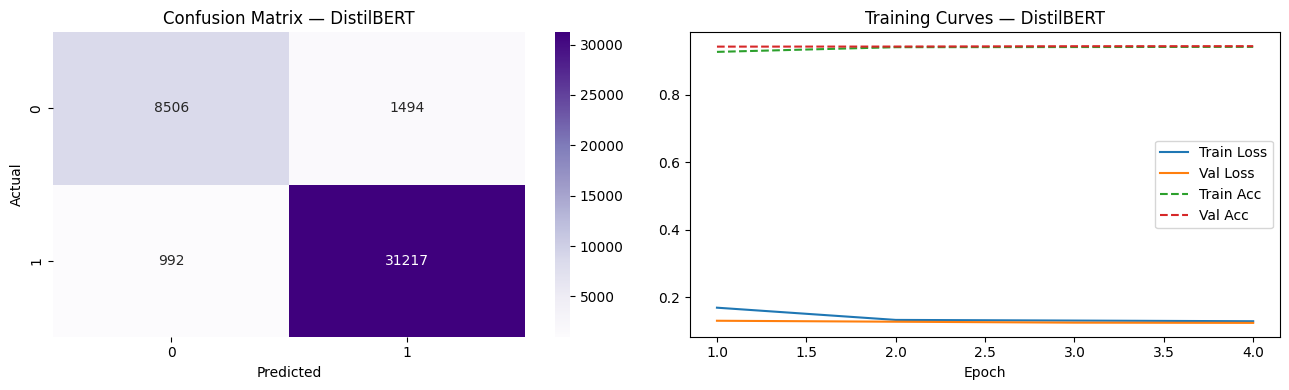

In [6]:
# ── 1. DistilBERT ───────────────────────────────────────────
# Fastest — 66M params, ~97% of BERT performance
run_transformer(
    model_name='distilbert-base-uncased',
    display_name='DistilBERT',
    max_len=128, epochs=4, batch_size=32, lr=2e-5
)


  Model: BERT-base
  Checkpoint: bert-base-uncased


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/4 | Train Loss: 0.1697 Acc: 0.9295 | Val Loss: 0.1364 Acc: 0.9407
  Epoch 2/4 | Train Loss: 0.1379 Acc: 0.9395 | Val Loss: 0.1297 Acc: 0.9422
  Epoch 3/4 | Train Loss: 0.1346 Acc: 0.9403 | Val Loss: 0.1284 Acc: 0.9430
  Epoch 4/4 | Train Loss: 0.1320 Acc: 0.9409 | Val Loss: 0.1266 Acc: 0.9433

─────────────────────────────────────────────────────────────────
  Test Results — BERT-base
─────────────────────────────────────────────────────────────────
  Accuracy  : 0.9409
  Precision : 0.9402  (weighted)
  Recall    : 0.9409  (weighted)
  F1-Score  : 0.9404  (weighted)
  ROC-AUC   : 0.9838
  MCC       : 0.8341
  Cohen's κ : 0.8336
  Parameters: 109,483,778
  Train Time: 34991.0s  |  Infer Time: 171.064s

Classification Report:
              precision    recall  f1-score   support

           0     0.8960    0.8492    0.8720     10000
           1     0.9539    0.9694    0.9616     32209

    accuracy                         0.9409     42209
   macro avg     0.9249    0.9093    

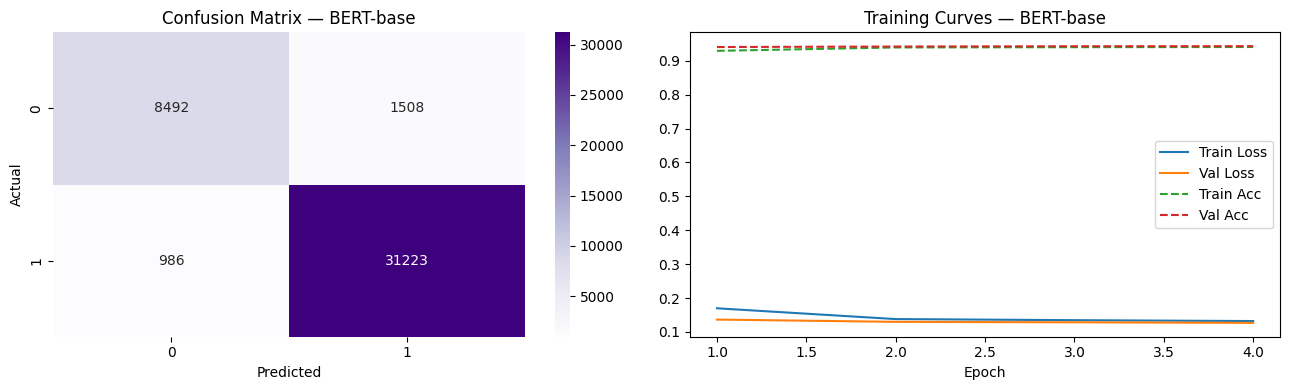

In [7]:
# ── 2. BERT-base ─────────────────────────────────────────────
# Most cited baseline — 110M params
run_transformer(
    model_name='bert-base-uncased',
    display_name='BERT-base',
    max_len=128, epochs=4, batch_size=16, lr=2e-5
)


  Model: RoBERTa-base
  Checkpoint: roberta-base


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/4 | Train Loss: 0.1782 Acc: 0.9259 | Val Loss: 0.1385 Acc: 0.9378
  Epoch 2/4 | Train Loss: 0.1450 Acc: 0.9384 | Val Loss: 0.1340 Acc: 0.9421
  Epoch 3/4 | Train Loss: 0.1399 Acc: 0.9395 | Val Loss: 0.1314 Acc: 0.9424
  Epoch 4/4 | Train Loss: 0.1371 Acc: 0.9403 | Val Loss: 0.1307 Acc: 0.9425

─────────────────────────────────────────────────────────────────
  Test Results — RoBERTa-base
─────────────────────────────────────────────────────────────────
  Accuracy  : 0.9405
  Precision : 0.9398  (weighted)
  Recall    : 0.9405  (weighted)
  F1-Score  : 0.9399  (weighted)
  ROC-AUC   : 0.9825
  MCC       : 0.8329
  Cohen's κ : 0.8324
  Parameters: 124,647,170
  Train Time: 8773.7s  |  Infer Time: 162.796s

Classification Report:
              precision    recall  f1-score   support

           0     0.8952    0.8481    0.8710     10000
           1     0.9536    0.9692    0.9613     32209

    accuracy                         0.9405     42209
   macro avg     0.9244    0.9086  

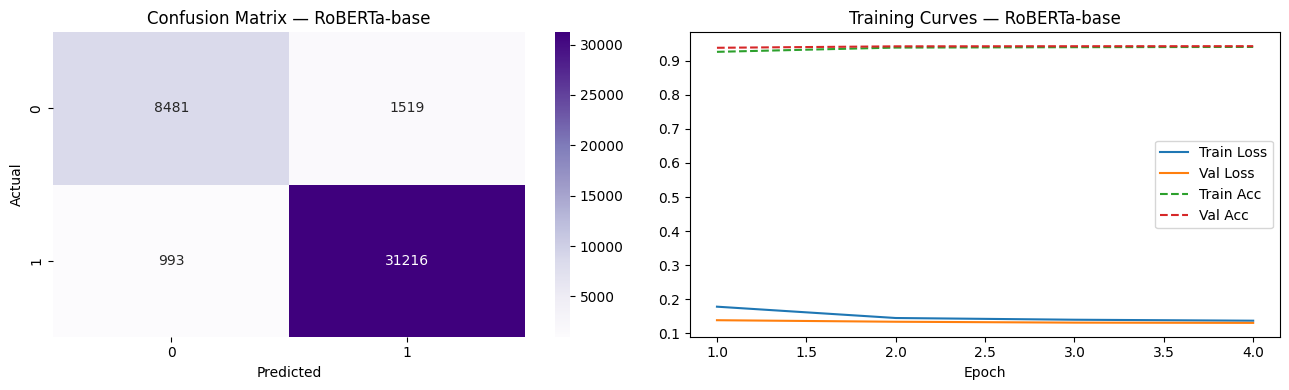

In [8]:
# ── 3. RoBERTa-base ──────────────────────────────────────────
# Often outperforms BERT — trained with more data & better masking
run_transformer(
    model_name='roberta-base',
    display_name='RoBERTa-base',
    max_len=128, epochs=4, batch_size=16, lr=2e-5
)

In [9]:
# ── SUMMARY TABLE ────────────────────────────────────────────
results_df = pd.DataFrame(results_table).sort_values('F1-Score', ascending=False).reset_index(drop=True)

print('\n' + '='*100)
print('         COMPARATIVE RESULTS TABLE — TRANSFORMER MODELS (TON_IoT NLP Dataset)')
print('='*100)
print(results_df.to_string(index=False))
print('='*100)

results_df.to_csv('transformer_results.csv', index=False)
print('Saved to transformer_results.csv')


         COMPARATIVE RESULTS TABLE — TRANSFORMER MODELS (TON_IoT NLP Dataset)
       Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC    MCC  Cohen's Kappa  Params(M)  Train Time(s)
  DistilBERT    0.9411     0.9404  0.9411    0.9406   0.9839 0.8347         0.8342       67.0         5322.5
   BERT-base    0.9409     0.9402  0.9409    0.9404   0.9838 0.8341         0.8336      109.5        34991.0
RoBERTa-base    0.9405     0.9398  0.9405    0.9399   0.9825 0.8329         0.8324      124.6         8773.7
Saved to transformer_results.csv


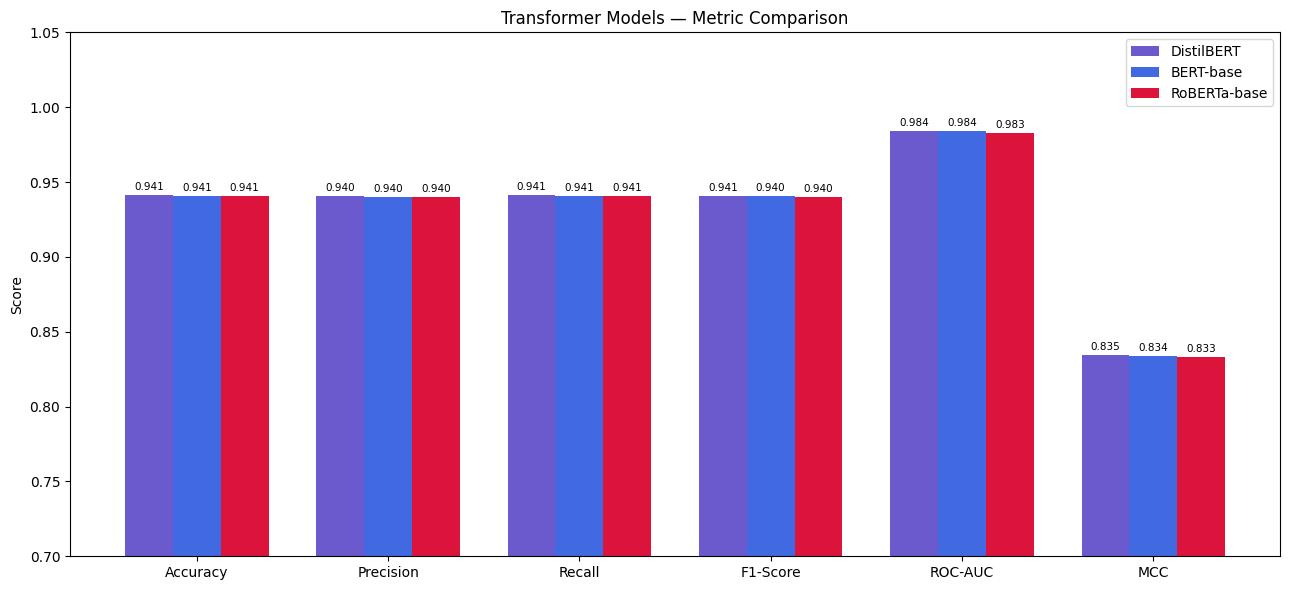

In [10]:
# ── Comparison Bar Chart ─────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'MCC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#6A5ACD', '#4169E1', '#DC143C']
for i, (_, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=row['Model'], color=colors[i])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_ylabel('Score'); ax.set_title('Transformer Models — Metric Comparison')
ax.set_xticks(x + width); ax.set_xticklabels(metrics)
ax.set_ylim(0.7, 1.05); ax.legend()
plt.tight_layout()
plt.savefig('transformer_comparison.png', dpi=150)
plt.show()

In [11]:
# ── MASTER COMBINED TABLE (Append with ML & DL results) ─────
# Run this after all 3 notebooks to generate the paper's Table

try:
    ml_df  = pd.read_csv('ml_results.csv')
    dl_df  = pd.read_csv('dl_results.csv')
    tr_df  = pd.read_csv('transformer_results.csv')

    ml_df['Category'] = 'ML'
    dl_df['Category'] = 'DL'
    tr_df['Category'] = 'Transformer'

    common = ['Category', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'MCC', "Cohen's Kappa"]
    master = pd.concat([
        ml_df[[c for c in common if c in ml_df.columns]],
        dl_df[[c for c in common if c in dl_df.columns]],
        tr_df[[c for c in common if c in tr_df.columns]]
    ], ignore_index=True)

    master = master.sort_values(['Category', 'F1-Score'], ascending=[True, False])
    master.to_csv('MASTER_results_all_models.csv', index=False)

    print('\n' + '='*110)
    print('    MASTER RESULTS TABLE — ALL MODELS (Ready for Research Paper)')
    print('='*110)
    print(master.to_string(index=False))
    print('='*110)
    print('\nSaved to MASTER_results_all_models.csv')
except FileNotFoundError:
    print('Run all 3 notebooks first to generate the master table.')


    MASTER RESULTS TABLE — ALL MODELS (Ready for Research Paper)
   Category               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC    MCC  Cohen's Kappa
         DL     CNN-LSTM Hybrid    0.9407     0.9400  0.9407    0.9401   0.9837 0.8335         0.8330
         DL             TextCNN    0.9402     0.9395  0.9402    0.9397   0.9834 0.8322         0.8317
         DL              Bi-GRU    0.9402     0.9394  0.9402    0.9396   0.9831 0.8319         0.8314
         DL Bi-LSTM + Attention    0.9398     0.9391  0.9398    0.9393   0.9829 0.8311         0.8307
         DL             Bi-LSTM    0.9398     0.9391  0.9398    0.9392   0.9833 0.8309         0.8304
         ML       Random Forest    0.9413     0.9406  0.9413    0.9408   0.9839 0.8354         0.8349
         ML             XGBoost    0.9412     0.9405  0.9412    0.9407   0.9840 0.8349         0.8345
         ML     SVM (LinearSVC)    0.9384     0.9377  0.9384    0.9378   0.9825 0.8270         0.8265
         ML Logi

## Notes for Research Paper
- **Fine-tuning config**: lr=2e-5, AdamW, linear warmup (10%), gradient clipping=1.0.
- **Max token length**: 128 (covers 95%+ of IoT log entries; increase to 256 if needed).
- **DistilBERT vs BERT**: DistilBERT is 2× faster with minimal accuracy drop — preferred for real-time IoT systems.
- **RoBERTa**: trained without NSP task; generally best for classification.
- Report best epoch from validation loss for final test evaluation.
- Include **parameter count** and **inference time** in the efficiency analysis section.
